In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
df = pd.read_csv("open-beer-database.csv")

# View basic info
print(df.head())
print(df.info())
print(df.describe())

                    Name  ...                                    Website
0           Scottish Ale  ...                                        NaN
1     Het Kapittel Pater  ...                                        NaN
2         Export Premium  ...                                        NaN
3    Bee Sting Honey Ale  ...                http://www.greatdivide.com/
4  PranQster Belgian Ale  ...  http://www.northcoastbrewing.com/home.htm

[5 rows x 22 columns]
<class 'pandas.DataFrame'>
RangeIndex: 5973 entries, 0 to 5972
Data columns (total 22 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Name                            5963 non-null   str    
 1   id                              5973 non-null   str    
 2   brewery_id                      5963 non-null   str    
 3   cat_id                          5950 non-null   str    
 4   style_id                        5949 non-null   str    
 5   Alcohol By 

In [3]:
# Drop rows with missing values (simple approach)
df = df.dropna()

# Example: inspect columns
print(df.columns)

Index(['Name', 'id', 'brewery_id', 'cat_id', 'style_id', 'Alcohol By Volume',
       'International Bitterness Units', 'Standard Reference Method',
       'Universal Product Code', 'filepath', 'Description', 'add_user',
       'last_mod', 'Style', 'Category', 'Brewer', 'Address', 'City', 'State',
       'Country', 'Coordinates', 'Website'],
      dtype='str')


In [4]:
# Example target column
target = "Style"

# Keep only numeric + useful columns (adjust as needed)
df = df.select_dtypes(include=[np.number]).join(df[target])

# Encode target labels
le = LabelEncoder()
df[target] = le.fit_transform(df[target])

# Split features and target
X = df.drop(columns=[target])
y = df[target]

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [7]:
dt_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=None,  # or try 5, 10, etc.
    min_samples_leaf=2
)

In [9]:
print("Decision Tree Confusion Matrix")
print(confusion_matrix(y_test, y_pred_dt))

print("\nRandom Forest Confusion Matrix")
print(confusion_matrix(y_test, y_pred_rf))

Decision Tree Confusion Matrix
[[0 0 0 0 0 0]
 [0 0 0 0 0 1]
 [1 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 1 0 0]
 [0 0 0 0 0 0]]

Random Forest Confusion Matrix
[[0 0 0 0 1]
 [0 0 1 0 0]
 [0 0 0 0 0]
 [0 0 1 0 0]
 [0 0 0 0 0]]


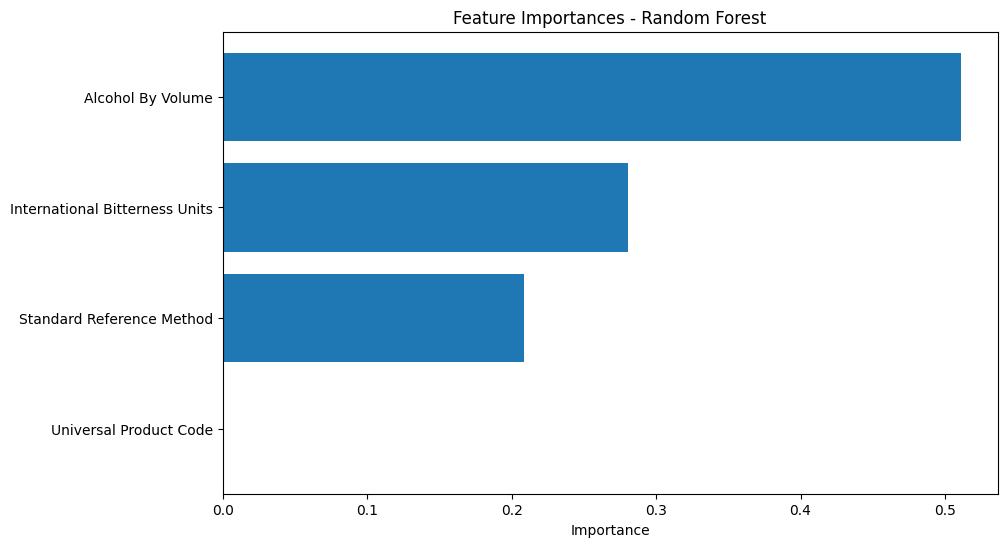

In [10]:
import matplotlib.pyplot as plt

importances = rf_model.feature_importances_
features = X.columns

indices = np.argsort(importances)

plt.figure(figsize=(10,6))
plt.title("Feature Importances - Random Forest")
plt.barh(range(len(indices)), importances[indices])
plt.yticks(range(len(indices)), features[indices])
plt.xlabel("Importance")
plt.show()